# 00.2 — Missing Data Diagnosis

Chẩn đoán và định vị các cột có dữ liệu thiếu, xác định dải thời gian khuyết (năm 2000) và kiểm tra tính toàn vẹn của dữ liệu từ năm 2001 đến 2026.


In [1]:
import sys
from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Reconfigure encoding
if hasattr(sys.stdout, 'reconfigure'):
    sys.stdout.reconfigure(encoding='utf-8', errors='replace')

ROOT_DIR = Path.cwd()
while not (ROOT_DIR / "src").exists() and ROOT_DIR != ROOT_DIR.parent:
    ROOT_DIR = ROOT_DIR.parent
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

from src.data.loader import DataLoader

# 1. Nạp dữ liệu thô (full 9,617 dòng x 36 cột)
df_raw = DataLoader().load_data(exclude_year_2000=False, drop_redundant_radiation=False)

missing_cols = [c for c in df_raw.columns if df_raw[c].isna().sum() > 0]
print("=" * 70)
print(f"🔍 1. DETECT: Phát hiện {len(missing_cols)} cột có dữ liệu thiếu:")
for col in missing_cols:
    n_miss = df_raw[col].isna().sum()
    print(f"   • {col:<30}: {n_miss:,} ô thiếu ({n_miss/len(df_raw)*100:.2f}%)")

# 2. LOCATE: Định vị mốc thời gian của dữ liệu thiếu
missing_mask = df_raw[missing_cols[0]].isna()
missing_dates = df_raw.loc[missing_mask, "Ngày"].sort_values()
print("\n📅 2. LOCATE: Thời gian khuyết dữ liệu:")
print(f"   • Ngày bắt đầu: {missing_dates.min().date()}")
print(f"   • Ngày kết thúc: {missing_dates.max().date()}")
print(f"   • Tổng số ngày khuyết: {len(missing_dates)} ngày (trọn vẹn năm nhuận 2000)")

# Kiểm tra dữ liệu từ 2001-01-01 trở đi
df_2001_onward = df_raw[df_raw["Ngày"] >= "2001-01-01"]
missing_2001_onward = df_2001_onward[missing_cols].isna().sum().sum()
print(f"   • Số ô thiếu từ 2001-01-01 đến 2026-04-30 ({len(df_2001_onward):,} ngày): {missing_2001_onward} ô (0.0%)")


🔍 1. DETECT: Phát hiện 5 cột có dữ liệu thiếu:
   • Bức xạ trực tiếp pháp tuyến   : 366 ô thiếu (3.81%)
   • Bức xạ quang hợp trời quang   : 366 ô thiếu (3.81%)
   • Bức xạ UVA                    : 366 ô thiếu (3.81%)
   • Bức xạ UVB                    : 366 ô thiếu (3.81%)
   • Chỉ số UV                     : 366 ô thiếu (3.81%)

📅 2. LOCATE: Thời gian khuyết dữ liệu:
   • Ngày bắt đầu: 2000-01-01
   • Ngày kết thúc: 2000-12-31
   • Tổng số ngày khuyết: 366 ngày (trọn vẹn năm nhuận 2000)
   • Số ô thiếu từ 2001-01-01 đến 2026-04-30 (9,251 ngày): 0 ô (0.0%)


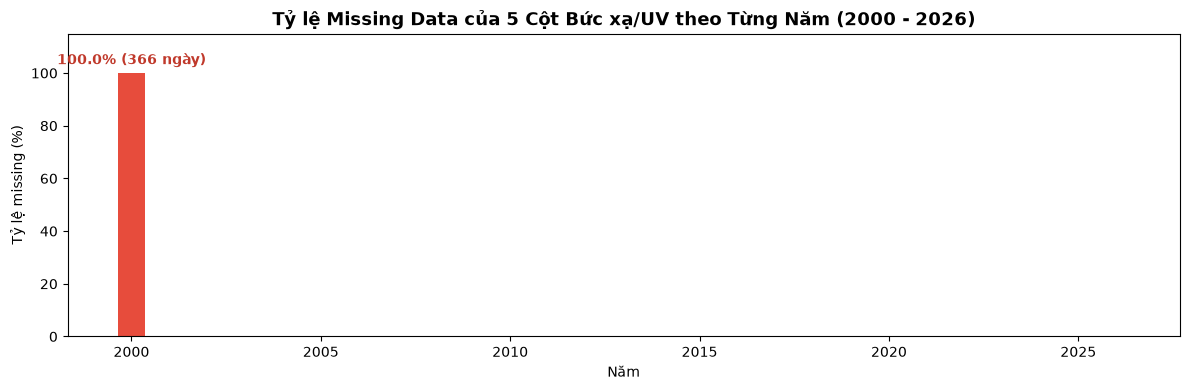

In [2]:
# 3. Trực quan hóa Tỷ lệ Missing theo Năm (2000 - 2026)
plt.figure(figsize=(12, 4))
years = df_raw["Ngày"].dt.year.unique()
pct_missing = [df_raw[df_raw["Ngày"].dt.year == y][missing_cols[0]].isna().mean() * 100 for y in years]

bar_colors = ['#e74c3c' if pct > 0 else '#2ecc71' for pct in pct_missing]
bars = plt.bar(years, pct_missing, color=bar_colors, width=0.7)
plt.title("Tỷ lệ Missing Data của 5 Cột Bức xạ/UV theo Từng Năm (2000 - 2026)", fontsize=13, fontweight='bold')
plt.xlabel("Năm")
plt.ylabel("Tỷ lệ missing (%)")
plt.ylim(0, 115)

for bar in bars:
    h = bar.get_height()
    if h > 0:
        plt.annotate(f'{h:.1f}% (366 ngày)',
                     xy=(bar.get_x() + bar.get_width() / 2, h),
                     xytext=(0, 4), textcoords="offset points",
                     ha='center', va='bottom', fontweight='bold', color='#c0392b')

plt.tight_layout()
plt.show()


In [3]:
# 4. Ghi nhận Quyết định Missing Data Policy
OUTPUT_DIR = ROOT_DIR / "notebooks" / "data_quality" / "outputs"

missing_policy_report = {
    "missing_features_detected": missing_cols,
    "missing_count_per_feature": 366,
    "missing_temporal_window": {
        "start": "2000-01-01",
        "end": "2000-12-31",
        "days": 366
    },
    "root_cause_diagnosis": "Structural / System-driven Missingness (Sensor / product availability: measurements were not collected by NASA POWER prior to 2001)",
    "recoverability_assessment": "Reconstruction of 366 consecutive days of solar radiation data is not defensible. Imputation would introduce artificial values, distort diurnal/seasonal physics, and risk data leakage.",
    "handling_decision": {
        "action": "Exclude year 2000 observations (366 days)",
        "retained_period": "2001-01-01 to 2026-04-30",
        "retained_features_policy": "Keep all 36 original features; feature redundancy evaluation is strictly delegated to EDA.",
        "imputation_performed": False
    }
}

artifact_path = OUTPUT_DIR / "missing_diagnosis_report.json"
with open(artifact_path, "w", encoding="utf-8") as f:
    json.dump(missing_policy_report, f, indent=2, ensure_ascii=False)

print(f"💾 Missing diagnosis report exported to: {artifact_path}")
print("   • Policy: Exclude year 2000 (366 days), retain all 36 features for 2001-2026.")


💾 Missing diagnosis report exported to: D:\DS108_project\notebooks\data_quality\outputs\missing_diagnosis_report.json
   • Chính sách: LOẠI BỎ NĂM 2000, GIỮ NGUYÊN 36 CỘT
   • Lý do: Structural/System-driven missingness, không bịa dữ liệu bằng imputation
